In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import re

In [2]:
sns.set_style("whitegrid")

In [3]:
path_model = '../models/tier_classifier.pkl'
model = joblib.load(path_model)

In [4]:
df_raw = pd.read_csv('../data/raw/vehicles.csv')

In [5]:
print(f"Dataset Raw cargado: {df_raw.shape}")

Dataset Raw cargado: (426880, 26)


In [6]:
def etiquetar_test_cars(row):
    manuf = str(row['manufacturer']).lower()
    model = str(row['model']).lower()

    # --- CASO 1: GMC SIERRA ---
    # Atrapamos 'sierra', 'sierra 1500' y también los genéricos '1500' si son GMC
    if 'gmc' in manuf:
        if 'sierra' in model:
            return 'GMC Sierra 1500'
        if model.strip() == '1500': # Si el modelo es solo "1500" y es GMC
            return 'GMC Sierra 1500'

    # --- CASO 2: HONDA ACCORD ---
    # Atrapamos 'accord'
    if 'honda' in manuf and 'accord' in model:
        return 'Honda Accord'

    return None

In [7]:
df_raw['test_model_unified'] = df_raw.apply(etiquetar_test_cars, axis=1)

In [8]:
df_test = df_raw.dropna(subset=['test_model_unified']).copy()

In [9]:
df_test['model_original'] = df_test['model'] # Guardamos el original por si acaso
df_test['model'] = df_test['test_model_unified']

In [10]:
df_test = df_test[
    (df_test['price'] > 1000) & (df_test['price'] < 100000) &
    (df_test['year'] > 2000) &
    (df_test['odometer'] > 1000) & (df_test['odometer'] < 400000) &
    (df_test['title_status'] == 'clean')
]

In [11]:
print(f"✅ Total coches encontrados para el test: {df_test.shape[0]}")
print("Desglose:")
print(df_test['model'].value_counts())

✅ Total coches encontrados para el test: 11037
Desglose:
model
GMC Sierra 1500    6988
Honda Accord       4049
Name: count, dtype: int64


In [13]:
def clean_cylinders_test(val):
    if pd.isna(val): return 6 # Valor por defecto conservador
    match = re.search(r'(\d+)', str(val))
    return int(match.group(1)) if match else 6

df_test['cylinders_num'] = df_test['cylinders'].apply(clean_cylinders_test)

In [14]:
cols_cat_model = ['manufacturer', 'model', 'fuel', 'drive', 'transmission', 'type', 'paint_color', 'condition']
for col in cols_cat_model:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('unknown')
    else:
        df_test[col] = 'unknown'

In [15]:
df_test['predicted_tier'] = model.predict(df_test)

In [16]:
print(df_test.groupby('model')['predicted_tier'].value_counts().unstack().fillna(0))

predicted_tier     1     2     3     4
model                                 
GMC Sierra 1500  978    31  2518  3461
Honda Accord     623  2382   303   741


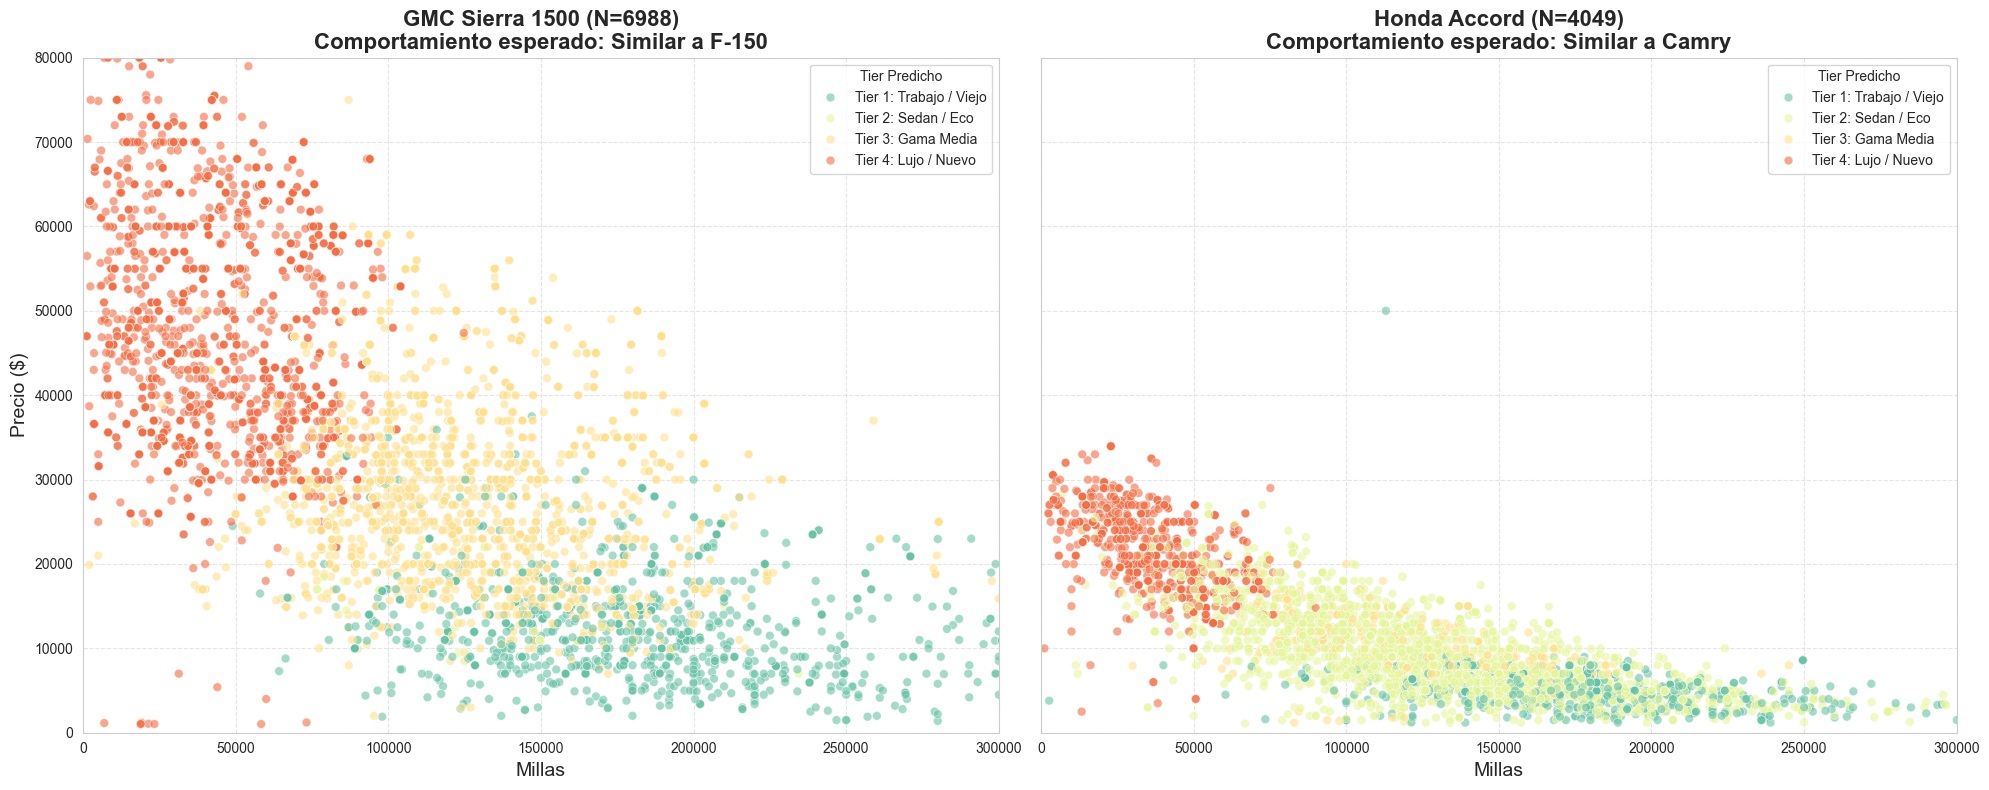

In [18]:
sns.set_style("whitegrid")

# Etiquetas para que la leyenda se entienda
tier_labels = {
    1: 'Tier 1: Trabajo / Viejo',
    2: 'Tier 2: Sedan / Eco',
    3: 'Tier 3: Gama Media',
    4: 'Tier 4: Lujo / Nuevo'
}
df_test['tier_cat'] = df_test['predicted_tier'].map(tier_labels)
order_tiers = [tier_labels[1], tier_labels[2], tier_labels[3], tier_labels[4]]

# GRÁFICO COMPARATIVO
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# GRÁFICO 1: GMC SIERRA (Esperamos ver un arcoíris completo como en las Pickups)
subset_gmc = df_test[df_test['model'] == 'GMC Sierra 1500']
sns.scatterplot(
    data=subset_gmc,
    x='odometer',
    y='price',
    hue='tier_cat',
    hue_order=order_tiers,
    palette='Spectral_r',
    alpha=0.6,
    s=40,
    ax=axes[0]
)
axes[0].set_title(f'GMC Sierra 1500 (N={len(subset_gmc)})\nComportamiento esperado: Similar a F-150', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Millas', fontsize=14)
axes[0].set_ylabel('Precio ($)', fontsize=14)
axes[0].set_xlim(0, 300000)
axes[0].set_ylim(0, 80000)
axes[0].legend(loc='upper right', title='Tier Predicho')
axes[0].grid(True, linestyle='--', alpha=0.5)

# GRÁFICO 2: HONDA ACCORD (Esperamos ver casi todo verde/amarillo, Tier 2 y 3)
subset_honda = df_test[df_test['model'] == 'Honda Accord']
sns.scatterplot(
    data=subset_honda,
    x='odometer',
    y='price',
    hue='tier_cat',
    hue_order=order_tiers,
    palette='Spectral_r',
    alpha=0.6,
    s=40,
    ax=axes[1]
)
axes[1].set_title(f'Honda Accord (N={len(subset_honda)})\nComportamiento esperado: Similar a Camry', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Millas', fontsize=14)
axes[1].set_xlim(0, 300000)
axes[1].legend(loc='upper right', title='Tier Predicho')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()